# Differential extinction and re-binning by extinction

Maps made from the stellar catalog contain integrated information: `E_map_int[i]` is the extinction due to dust accumulated from the observer to distance bin `i`. To visualize extinction due to dust in a single distance slice, we can make maps of

- **Delta E**, `E_int[i] - E_int[i-1]`, and
- **Differential E**, `Delta E / Delta d`.

Unfortunately, differential extinction maps are often very poor resolution, especially at far distances, where there are few stars and little dust. In Section 3, we create coarse distance bins so that each bin has about the same amount of
extinction above a minimum value. Section 4 builds new maps using the coarse bins.

1. Load integrated maps
2. Integrated to differential
3. Re-bin so each bin carries equal extinction
4. Coarse differential maps
5. Plot

In [1]:
# Autoreload so we don't have to restart the kernel every time we change source code
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# Astronomy packages
import h5py as h5
import healpy as hp
import astropy.units as u
from astropy.coordinates import SkyCoord
# My packages
import utils
import loader
from constants import data_dir, plt_dir

## 1. Load the integrated maps

In [3]:
"""Load the Zhang & Green integrated extinction maps and the distance bin edges."""
ZhangGreen = loader.HDF5Loader(data_dir, 'Rv_map_new.h5')
E_map_int_64 = ZhangGreen.load_data(['map_64/E_map_int'])
all_distances = ZhangGreen.load_data(['distance_bins'])
NSIDE = 64
NEST = True
print(E_map_int_64.shape, all_distances.shape)

Loading ['map_64/E_map_int'] from disk into RAM (this happens only once)...
Loading ['distance_bins'] from disk into RAM (this happens only once)...
(25, 49152) (26,)


In [4]:
"""Initialize the CMB and Galactic BK fields."""
cmb = loader.Field('CMB', data_dir)
gal = loader.Field('GAL', data_dir)

## 2. Integrated to differential

In [5]:
def int2diff(int_map, dist_edges):
    """Convert an integrated extinction map to differential and delta maps.

    Returns (diff_map, delta_map):
      delta_map[i] = extinction accumulated inside shell i          [mag]
      diff_map[i]  = delta_map[i] / (width of shell i)              [mag/kpc]"""
    widths = np.diff(dist_edges)
    delta_map = np.vstack((int_map[0], np.diff(int_map, axis=0)))
    diff_map = delta_map / widths[:, np.newaxis]
    return diff_map, delta_map

In [6]:
E_map_diff_64, E_map_delta_64 = int2diff(E_map_int_64, all_distances)
print(E_map_diff_64.shape, E_map_delta_64.shape)

(25, 49152) (25, 49152)


### Extinction as a function of distance

The bins used in Zhang and Green 2025 do not contain equal amounts of extinction. This is why we want to rebin.

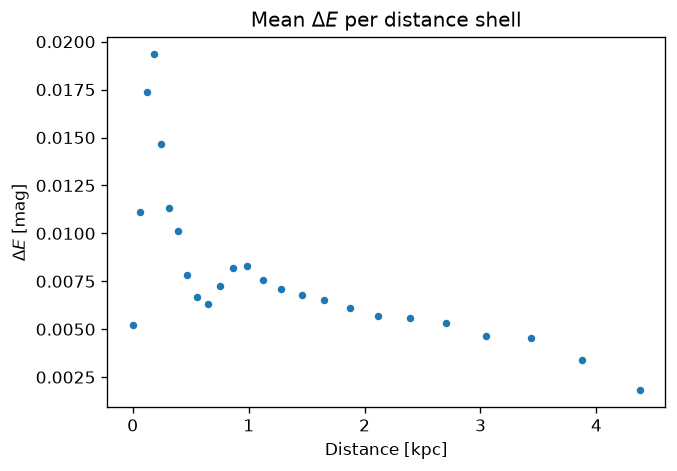

total mean extinction over all shells: 0.199 mag


In [7]:
avg_ext = np.nanmean(E_map_delta_64, axis=1)

fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.scatter(all_distances[:-1], avg_ext, s=12)
ax.set_title(r'Mean $\Delta E$ per distance shell')
ax.set_xlabel('Distance [kpc]')
ax.set_ylabel(r'$\Delta E$ [mag]')
#ax.set_xscale('log')
plt.show()

print(f"total mean extinction over all shells: {avg_ext.sum():.3f} mag")

## 3. Re-bin so each bin carries equal extinction

`rebin_by_extinction` walks the fine shells, accumulating `Delta E`, and closes a coarse
bin whenever the accumulated extinction reaches `target_ext`. At each candidate edge it
picks whichever of the two neighboring fine edges lands closer to the target.

Give it either a `target_ext` in mag, or an `n_bins` to hit on average.

In [8]:
def rebin_by_extinction(fine_edges, diff_ext, target_ext=None, n_bins=None,
                        min_frac=0.5):
    """Group fine distance shells into coarser bins of roughly equal total extinction.

    Parameters
    ----------
    fine_edges : array, shape (N+1,)
        Original bin edges, e.g. the 26-element `all_distances`.
    diff_ext : array, shape (N,)
        Extinction accumulated in each fine shell; diff_ext[i] corresponds to
        [fine_edges[i], fine_edges[i+1]].
    target_ext : float, optional
        Desired extinction per new bin. If None, computed from n_bins.
    n_bins : int, optional
        Desired number of output bins; used only if target_ext is None.
    min_frac : float
        If the final leftover bin holds less than min_frac * target_ext, merge it
        into the previous bin rather than leaving it standalone.

    Returns
    -------
    new_edges : array
        Coarse bin edges, a subset of fine_edges.
    achieved_ext : list
        Extinction summed into each output bin, for validation."""
    fine_edges = np.asarray(fine_edges)
    diff_ext = np.asarray(diff_ext)
    total_ext = diff_ext.sum()

    if target_ext is None:
        if n_bins is None:
            raise ValueError("Provide either target_ext or n_bins.")
        target_ext = total_ext / n_bins

    new_edges = [fine_edges[0]]
    achieved_ext = []
    cum = 0.0

    for i, deltaE in enumerate(diff_ext):
        cum += deltaE
        if cum >= target_ext:
            overshoot = cum - target_ext
            undershoot = target_ext - (cum - deltaE)
            if overshoot <= undershoot:
                # Stopping AFTER including shell i is closer to the target
                new_edges.append(fine_edges[i + 1])
                achieved_ext.append(cum)
                cum = 0.0
            else:
                # Stopping BEFORE shell i (cut at edge i) is closer
                new_edges.append(fine_edges[i])
                achieved_ext.append(cum - deltaE)
                cum = deltaE   # the current shell rolls into the next bin

    # Leftover extinction that never reached target_ext
    if cum > 0:
        if len(achieved_ext) > 0 and cum < min_frac * target_ext:
            # Too small to stand alone -- merge into the previous bin
            new_edges[-1] = fine_edges[-1]
            achieved_ext[-1] += cum
        else:
            new_edges.append(fine_edges[-1])
            achieved_ext.append(cum)

    return np.array(new_edges), achieved_ext

In [9]:
def edges_to_indices(coarse_edges, fine_edges):
    """Index into `fine_edges` of each coarse edge. `rebin_by_extinction` returns a
    subset of the fine edges, so every coarse edge matches one exactly."""
    return [int(np.argmax(fine_edges == edge)) for edge in coarse_edges]

In [10]:
TARGET_EXT = 0.05   # mag of extinction per coarse bin

coarse_edges, achieved = rebin_by_extinction(all_distances, avg_ext, TARGET_EXT)
coarse_indices = edges_to_indices(coarse_edges, all_distances)

print(f"{len(coarse_edges) - 1} coarse bins from {len(all_distances) - 1} fine shells")
for i, ext in enumerate(achieved):
    print(f"  bin {i}: {coarse_edges[i]:6.3f} - {coarse_edges[i + 1]:6.3f} kpc  "
          f"E = {ext:.4f} mag")
print("fine-edge indices:", coarse_indices)

4 coarse bins from 25 fine shells
  bin 0:  0.000 -  0.248 kpc  E = 0.0531 mag
  bin 1:  0.248 -  0.647 kpc  E = 0.0505 mag
  bin 2:  0.647 -  1.652 kpc  E = 0.0515 mag
  bin 3:  1.652 -  4.934 kpc  E = 0.0437 mag
fine-edge indices: [0, 4, 9, 16, 25]


## 4. Coarse differential maps

Pixels where the integrated extinction decreases with distance are unphysical, a
sign that a pixel has too few stars to constrain that shell. They are set to `NaN` here.

In [12]:
def make_coarse_differential_E_map(int_map, coarse_edge_indices, dist_edges):
    """Differential and delta extinction maps on a coarse binning.

    coarse_edge_indices : indices into `dist_edges` of the coarse bin edges,
                          as returned by `edges_to_indices`.

    Returns (diff_map, delta_map) with negative pixels set to NaN."""
    n_coarse = len(coarse_edge_indices) - 1
    n_fine = int_map.shape[0]
    delta_map = np.empty((n_coarse, int_map.shape[1]), dtype=np.float64)
    for i in range(n_coarse):
        hi = coarse_edge_indices[i + 1]
        lo = coarse_edge_indices[i]
        # The last coarse edge indexes the outer edge of the final shell, which is
        # one past the last row of int_map.
        hi = min(hi, n_fine - 1)
        delta_map[i] = int_map[hi] - int_map[lo]

    widths = np.diff(dist_edges[coarse_edge_indices])
    diff_map = delta_map / widths[:, np.newaxis]

    # Quality cuts: extinction cannot decrease with distance
    bad = (delta_map < 0) | (diff_map < 0)
    delta_map[bad] = np.nan
    diff_map[bad] = np.nan
    return diff_map, delta_map

In [13]:
diff_E_coarse, delta_E_coarse = make_coarse_differential_E_map(
    E_map_int_64, coarse_indices, all_distances)
print(diff_E_coarse.shape)
print(f"{np.isnan(delta_E_coarse).sum():,} of {delta_E_coarse.size:,} pixels "
      f"cut")

(4, 49152)
16,053 of 196,608 pixels cut


## 5. Plot

A copy of the full-sky galactic plotting function, with the colour label and limits
adapted for differential maps.

In [14]:
def plot_diff_ext(ext_map, title, nest=True, vmin=None, vmax=None,
                  cbar_label=r"$\Delta E$ [mag]", save=False, fname=None):
    """Plot a differential or delta extinction map, half sky, galactic coordinates."""
    hp.orthview(ext_map,
                coord=['G'],
                rot=[0, 0, 0],
                nest=nest,
                half_sky=True,
                title=title,
                cmap='inferno',
                badcolor='white',
                min=vmin, max=vmax,
                cbar=False,
                notext=True,
                hold=True)
    # Graticule
    hp.graticule(dpar=10, dmer=20)
    # Axes
    ax = plt.gca()
    ax.text(0.0, -1 - 0.06, "Galactic longitude [deg]", fontsize=10,
            va='top', ha='center', color='black')
    ax.text(-1 - 0.2, 0.0, "Galactic latitude [deg]", fontsize=10, rotation=90,
            va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink=0.5)
    cbar.set_label(cbar_label, fontsize=10, labelpad=10)
    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

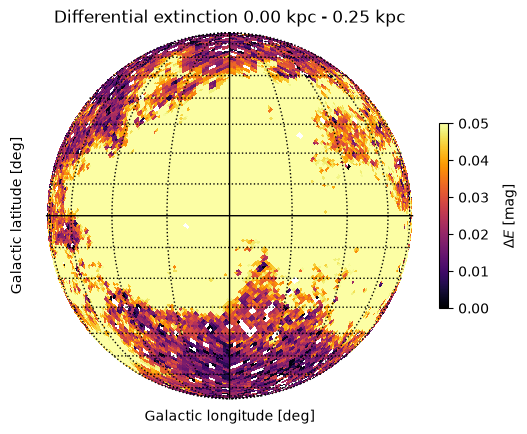

In [15]:
i = 0
plot_diff_ext(delta_E_coarse[i],
              f"Differential extinction "
              f"{coarse_edges[i]:.2f} kpc - {coarse_edges[i + 1]:.2f} kpc",
              nest=NEST, vmin=0, vmax=TARGET_EXT)

Rendering every coarse bin to `plt_dir` gives a frame sequence that the appendix of
`make_video.ipynb` turns into a video. Zero-pad the frame number so the files
sort correctly.

In [ ]:
FRAME_DIR = os.path.join(plt_dir, f'delta_E_{TARGET_EXT:.2f}')
os.makedirs(FRAME_DIR, exist_ok=True)

for i in range(delta_E_coarse.shape[0]):
    plot_diff_ext(delta_E_coarse[i],
                  f"Differential extinction "
                  f"{coarse_edges[i]:.2f} kpc - {coarse_edges[i + 1]:.2f} kpc",
                  nest=NEST, vmin=0, vmax=TARGET_EXT,
                  save=True,
                  fname=os.path.join(FRAME_DIR, f"delta_E_{i:03d}.png"))
print(f"wrote {delta_E_coarse.shape[0]} frames to {FRAME_DIR}")